In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kevinnadar22/mumbai-house-price-data-70k-entries")

print("Path to dataset files:", path)

100%|██████████| 1.76M/1.76M [00:00<00:00, 40.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kevinnadar22/mumbai-house-price-data-70k-entries/versions/3


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import lightgbm as lgb

In [ ]:
csv_path = os.path.join(path, 'mumbai-house-price-data-cleaned.csv')
df = pd.read_csv(csv_path)

In [ ]:
df.head()


,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,Octave Parijas Horizon,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,Shakti Siyara Heights,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,Bhagwati Bhagwati Celeste,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Ope...,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,J P Ruchita Bliss,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319


In [ ]:
df['age'].unique()
df['area'].max()

20000

In [ ]:
df['total_floors'].describe()

,total_floors
count,71578.000000
mean,1.004191
std,0.375358
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,70.000000


In [ ]:

df.shape


(71938, 15)

In [ ]:
def pct_method(data, level):
    # Upper and lower limits by percentiles
    upper = np.percentile(data, 100 - level)
    lower = np.percentile(data, level)
    # Returning the upper and lower limits
    return [lower, upper]

In [ ]:
def iqr_method(data):
    # Calculating the IQR
    perc_75 = np.percentile(data, 75)
    perc_25 = np.percentile(data, 25)
    iqr_range = perc_75 - perc_25
    # Obtaining the lower and upper bound
    iqr_upper = perc_75 + 1.5 * iqr_range
    iqr_lower = perc_25 - 1.5 * iqr_range
    # Returning the upper and lower limits
    return [iqr_lower, iqr_upper]

In [ ]:
def outlier_bool(data, level=0.5, continuous=False, log=False):


  if log is True:

    data = np.log(data + 1)

  pct_range = pct_method(data, level)
  iqr_range = iqr_method(data)

  if continuous is False:


    low_limit = np.min(data)
    high_limit = np.max([pct_range[1],iqr_range[1]])
  elif continuous is True:

    low_limit = np.min([pct_range[0],iqr_range[0]])
    high_limit = np.max([pct_range[1],
                             iqr_range[1]
                             ])

  outlier = data.between(low_limit, high_limit)

  return outlier

In [ ]:
outlier=outlier_bool(df['price_per_sqft'],0.5,True,False)

In [ ]:
df=df[outlier]

In [ ]:
df.drop(['price','title','latitude','longitude','city'], axis=1, inplace=True)

In [ ]:
num_features = ['bedroom_num','bathroom_num','balcony_num','total_floors']
cat_features = ['locality','property_type']
ordinal_features = ['furnished']
log_features = ["age", "area"]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer


log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p,feature_names_out='one-to-one', validate=False)),
    ('scaler', StandardScaler())
])
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])



from sklearn.preprocessing import OrdinalEncoder

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['Unfurnished', 'Semi-Furnished', 'Furnished']]
    )),
    #('scaler', StandardScaler())  # optional but recommended for GD
])


from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('log',log_pipeline,log_features),
        ('num', num_pipeline, num_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('cat', cat_pipeline, cat_features)
    ]
)


In [ ]:
X=df.drop('price_per_sqft', axis=1)
y=df['price_per_sqft']

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [ ]:
type(X_train) == pd.DataFrame


True

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
X_test_processed.shape


(23621, 376)

In [ ]:
from sklearn.compose import TransformedTargetRegressor


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(model, X_train, y_train,X_val,y_val):

    train_errors, val_errors = [], []

    train_sizes = np.linspace(500, len(X_train), 20, dtype=int)
    for m in train_sizes:
        model.fit(X_train[:m], y_train[:m])

        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)

        train_errors.append(
            mean_squared_error(y_train[:m], y_train_predict)
        )
        val_errors.append(
            mean_squared_error(y_val, y_val_predict)
        )

    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
polynomial_regression = Pipeline([
 ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
 ("lin_reg", LinearRegression()),
 ])

In [ ]:

#plot_learning_curves(polynomial_regression,X_train_processed, y_train,X_test_processed,y_test)

In [ ]:
df['locality'].value_counts(ascending=False).head(150)

,count
locality,
Thane,8208
Mira Road,4861
Kandivali,2930
Kharghar,2843
Andheri,2659
...,...
Khadakpada,8
Worli Sea Fase,7
Khalapur,7


In [ ]:
df.city.value_counts()

,count
city,
Mumbai,70573
Western Mumbai,470
Central Mumbai,361
Mumbai South,156


In [ ]:
df.columns

Index(['price', 'area', 'locality', 'city', 'property_type', 'bedroom_num',
       'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors'],
      dtype='object')

In [ ]:

feature_names = preprocessor.get_feature_names_out()

In [ ]:
print(X_train_processed.shape[1])
print(len(feature_names))


376
376


In [ ]:
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=y_train.index
)

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=y_test.index
)


In [ ]:
#X_train_df.drop(columns=['num__age','num__area'],axis=1,inplace=True)
#X_test_df.drop(columns=['num__age','num__area'],axis=1,inplace=True)


In [ ]:
def out_iqr(df , column):
    global lower,upper
    q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [ ]:
out_iqr(X_train_df,'log__area')

The IQR is 0.6137334696573298
The lower bound value is 5.469640462579355
The upper bound value is 7.924574341208674
Total number of outliers are 975


/tmp/ipython-input-467042120.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_df['log__area'], kde=False)


<Axes: xlabel='log__area'>

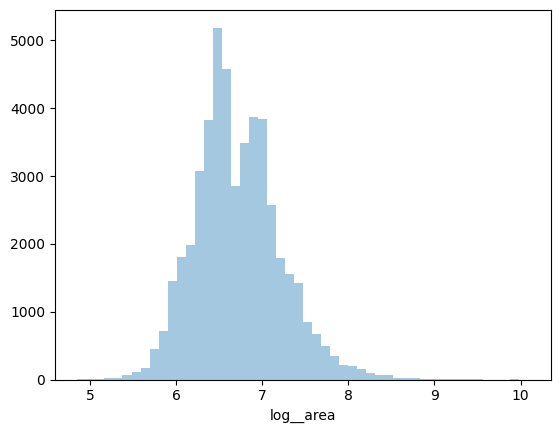

In [ ]:
sns.distplot(X_train_df['log__area'], kde=False)

<Axes: ylabel='log__area'>

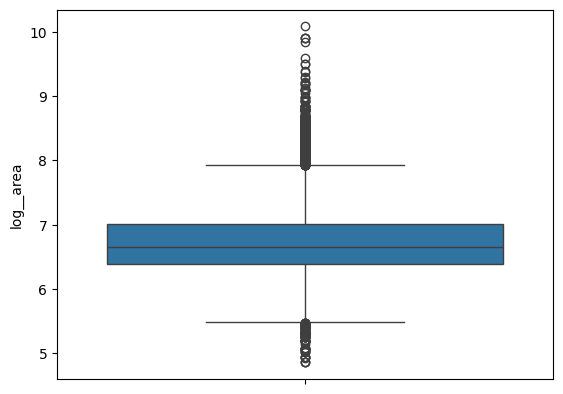

In [ ]:
sns.boxplot(X_train_df['log__area'])

In [ ]:
X_train_df['log__area'].describe()

,log__area
count,48198.000000
mean,6.711396
std,0.499829
min,4.852030
25%,6.390241
50%,6.656727
75%,7.003974
max,10.090382


/tmp/ipython-input-2514762328.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_df['log__area'], kde=False)


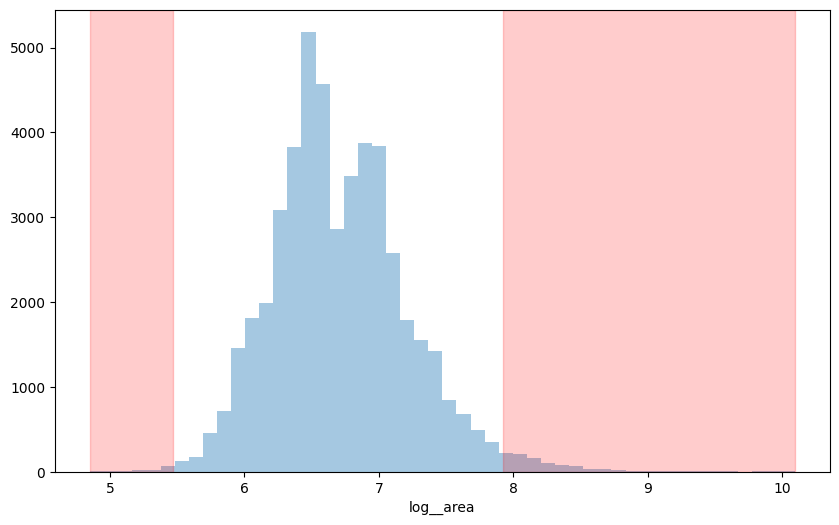

In [ ]:
plt.figure(figsize = (10,6))
sns.distplot(X_train_df['log__area'], kde=False)
plt.axvspan(xmin = lower,xmax= X_train_df['log__area'].min(),alpha=0.2, color='red')
plt.axvspan(xmin = upper,xmax= X_train_df['log__area'].max(),alpha=0.2, color='red')

In [ ]:
poly_features = ['log__area', 'log__age']

linear_features = (
    X_train_df
    .drop(columns=poly_features)
    .columns
    .tolist()
)




In [ ]:

preprocessor2 = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(degree=3, include_bias=False), poly_features),
        ('linear', 'passthrough', linear_features)
    ]

)

In [ ]:
model = Pipeline([
    ('features', preprocessor2),
    ('regressor', LinearRegression())


])


In [ ]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X_train_processed, y_train,X_test_processed,y_test)

KeyboardInterrupt: 

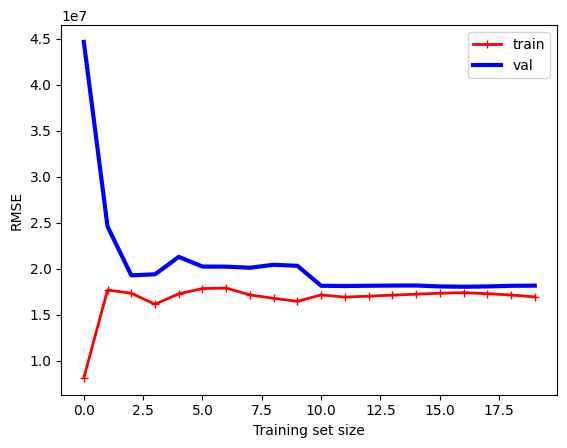

In [ ]:
plot_learning_curves(model, X_train_df, y_train,X_test_df,y_test)

In [ ]:
model.fit(  X_train_df, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('poly',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False),
                                                  ['log__area', 'log__age']),
                                                 ('linear', 'passthrough',
                                                  ['num__bedroom_num',
                                                   'num__bathroom_num',
                                                   'num__balcony_num',
                                                   'num__total_floors',
                                                   'ord__furnished',
                                                   'cat__locality_Adarsh Nagar',
                                                   'cat__locality_Additional '
                                                   'M.I.D.C',
                                                   'cat__locality_Agasan '
                                                   'V...
                                                   'cat__locality_Andheri',
                                                   'cat__locality_Anjurdive',
                                                   'cat__locality_Antop Hill',
                                                   'cat__locality_Anushakti '
                                                   'Nagar',
                                                   'cat__locality_Arya Nagar',
                                                   'cat__locality_Asalpha',
                                                   'cat__locality_Asangaon',
                                                   'cat__locality_Ashok Nagar',
                                                   'cat__locality_Atgaon',
                                                   'cat__locality_Babhai',
                                                   'cat__locality_Badlapur',
                                                   'cat__locality_Balkum',
                                                   'cat__locality_Bandra', ...])])),
                ('regressor', LinearRegression())])

In [ ]:
train_r2 = model.score(X_train_df, y_train)
test_r2  = model.score(X_test_df, y_test)

print("Train R²:", train_r2)
print("Test  R²:", test_r2)


Train R²: 0.728223351304192
Test  R²: 0.7245441420921439


In [ ]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1
                  , solver="auto")



In [ ]:
model2 = Pipeline([
    ('features', preprocessor2),
    ('ridge_regressor',ridge_reg)
])

In [ ]:
model2.fit(X_train_df, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('poly',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False),
                                                  ['log__area', 'log__age']),
                                                 ('linear', 'passthrough',
                                                  ['num__bedroom_num',
                                                   'num__bathroom_num',
                                                   'num__balcony_num',
                                                   'num__total_floors',
                                                   'ord__furnished',
                                                   'cat__locality_Adarsh Nagar',
                                                   'cat__locality_Additional '
                                                   'M.I.D.C',
                                                   'cat__locality_Agasan '
                                                   'V...
                                                   'cat__locality_Anjurdive',
                                                   'cat__locality_Antop Hill',
                                                   'cat__locality_Anushakti '
                                                   'Nagar',
                                                   'cat__locality_Arya Nagar',
                                                   'cat__locality_Asalpha',
                                                   'cat__locality_Asangaon',
                                                   'cat__locality_Ashok Nagar',
                                                   'cat__locality_Atgaon',
                                                   'cat__locality_Babhai',
                                                   'cat__locality_Badlapur',
                                                   'cat__locality_Balkum',
                                                   'cat__locality_Bandra', ...])])),
                ('ridge_regressor', Ridge(alpha=0.1))])

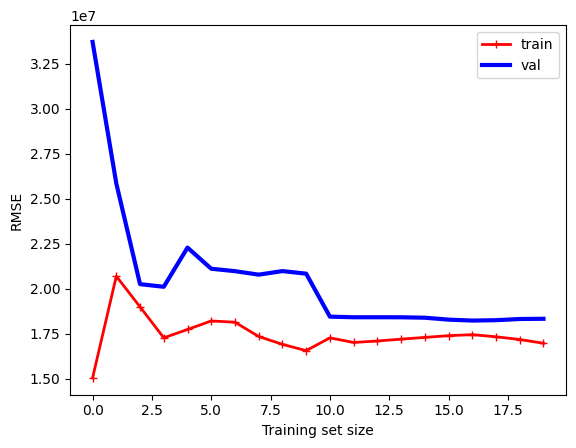

In [ ]:
plot_learning_curves(model2, X_train_df, y_train,X_test_df,y_test)

In [ ]:
train_r2 = model2.score(X_train_df, y_train)
test_r2  = model2.score(X_test_df, y_test)

print("Train R²:", train_r2)
print("Test  R²:", test_r2)


Train R²: 0.7270120735010384
Test  R²: 0.7191658358798729


In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
#tree_reg.fit(X_train_df, y_train)


DecisionTreeRegressor()

In [ ]:
def rmse(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(rmse)

In [ ]:
tree_reg.score(X_test_df, y_test)

0.7985325887172912

In [ ]:
print("Linear Regression R2:", model.score(X_test_df, y_test))



Linear Regression R2: 0.7245441420921439


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
forest_reg=RandomForestRegressor()

In [ ]:
#forest_reg.fit(X_train_df, y_train)

RandomForestRegressor()

In [ ]:
forest_reg.score(X_test_df, y_test)

0.8814241419251073

In [ ]:
forest_reg.score(X_train_df, y_train)


0.9721785092728626

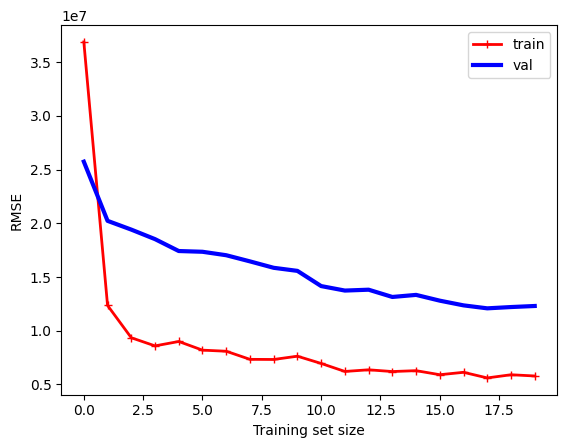

In [ ]:
#plot_learning_curves(forest_reg, X_train_df, y_train,X_test_df,y_test)


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = [
 {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
 {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
 ]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
 scoring='neg_mean_squared_error',
return_train_score=True)
grid_search.fit(X_train_df,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
forest_reg=RandomForestRegressor(max_features=4, n_estimators=10,bootstrap=False)

In [ ]:
forest_reg.fit(X_train_df, y_train)

RandomForestRegressor(bootstrap=False, max_features=4, n_estimators=10)

In [ ]:
forest_reg.score(X_test_df, y_test)

0.9032511556321741

In [ ]:
forest_reg.score(X_train_df, y_train)

0.9967940522453452

In [ ]:
rmse(forest_reg,X_test_df,y_test)

10769390.648691423


In [ ]:
rmse(forest_reg,X_train_df,y_train)


1840262.1235287623


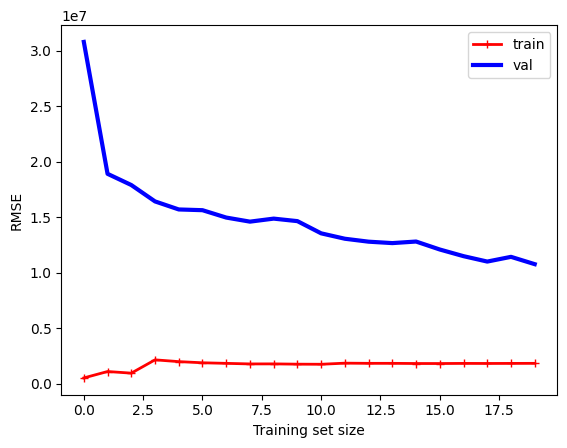

In [ ]:
plot_learning_curves(forest_reg, X_train_df, y_train,X_test_df,y_test)


In [ ]:
grid_search.score(X_train_df, y_train)


In [ ]:
grid_search.score(X_test_df, y_test)


In [ ]:
import xgboost
xgb_reg = xgboost.XGBRegressor()
xgb_reg.fit(X_train_df, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_reg.score(X_test_df, y_test)

0.8733125925064087

In [ ]:
xgb_reg.score(X_train_df, y_train)

0.9373915195465088

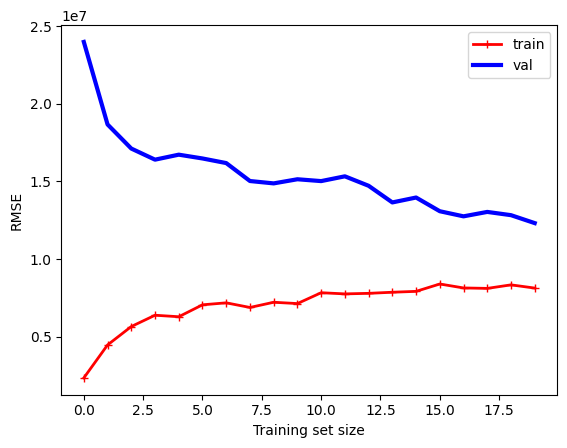

In [ ]:
plot_learning_curves(xgb_reg, X_train_df, y_train,X_test_df,y_test)

In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# -----------------------------
# Base model (do NOT overfit)
# -----------------------------
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

# -----------------------------
# Hyperparameter search space
# -----------------------------
param_dist = {
    "n_estimators": randint(800, 2000),
    "learning_rate": uniform(0.03, 0.07),   # ~0.03–0.10
    "max_depth": randint(4, 7),
    "min_child_weight": randint(10, 40),
    "subsample": uniform(0.65, 0.25),        # ~0.65–0.90
    "colsample_bytree": uniform(0.6, 0.3),   # ~0.6–0.9
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(1.0, 4.0)
}

# -----------------------------
# RandomizedSearchCV
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,                    # increase if you have more compute
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# Fit with early stopping
# -----------------------------
random_search.fit(
    X_train_df, y_train,
    eval_set=[(X_test_df, y_test)],

    #early_stopping_rounds=50,
    verbose=False
)

# -----------------------------
# Best model & scores
# -----------------------------
best_xgb = random_search.best_estimator_

print("Best Params:\n", random_search.best_params_)
print("Train R2:", best_xgb.score(X_train_df, y_train))
print("Test  R2:", best_xgb.score(X_test_df, y_test))


Fitting 3 folds for each of 40 candidates, totalling 120 fits


KeyboardInterrupt: 

In [ ]:
import re

def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in df.columns
    ]
    return df


In [ ]:
X_train_df = clean_feature_names(X_train_df)
X_test_df  = clean_feature_names(X_test_df)


In [ ]:
set(X_train_df.columns) == set(X_test_df.columns)


True

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

lgbm_fast_fixed = lgb.LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",
    random_state=42,
    verbosity=-1,
    force_row_wise=True,
    n_jobs=-1
)

param_dist = {
    "n_estimators": randint(400, 800),
    "learning_rate": uniform(0.04, 0.06),
    "num_leaves": randint(31, 80),          # 🔧 increased
    "max_depth": randint(5, 8),
    "min_child_samples": randint(20, 60),   # 🔧 relaxed
    "subsample": uniform(0.75, 0.2),
    "colsample_bytree": uniform(0.7, 0.2),
    "reg_alpha": uniform(0.05, 0.4),
     # 🔧 lower
    "reg_lambda": uniform(0.8, 2.5)
}

random_search = RandomizedSearchCV(
    estimator=lgbm_fast_fixed,
    param_distributions=param_dist,
    n_iter=8,
    cv=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1,

    verbose=1
)

random_search.fit(X_train_df, y_train)

best_lgbm = random_search.best_estimator_

print("Best Params:", random_search.best_params_)
print("Train R2:", best_lgbm.score(X_train_df, y_train))
print("Test  R2:", best_lgbm.score(X_test_df, y_test))


Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best Params: {'colsample_bytree': np.float64(0.709333132642723), 'learning_rate': np.float64(0.09842533113048754), 'max_depth': 7, 'min_child_samples': 22, 'n_estimators': 706, 'num_leaves': 37, 'reg_alpha': np.float64(0.11820964947491662), 'reg_lambda': np.float64(0.9626289824631988), 'subsample': np.float64(0.9397771074506667)}
Train R2: 0.8950552348184035
Test  R2: 0.835609771185168


In [ ]:
final_lgbm = lgb.LGBMRegressor(
    force_col_wise=True,
    objective="regression",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    max_depth=7,
    num_leaves=37,
    min_child_samples=22,
    reg_alpha=0.11820964947491662,
    reg_lambda=0.9626289824631988,
    subsample=0.9397771074506667,
    colsample_bytree=0.709333132642723,
    learning_rate=0.09842533113048754,
    n_estimators=706,
    verbosity=-1,
)

final_lgbm.fit(X_train_processed, y_train)

print("Train R2:", final_lgbm.score(X_train_processed, y_train))
print("Test  R2:", final_lgbm.score(X_test_processed, y_test))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train R2: 0.8326324749066838


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Test  R2: 0.8054586117360008


In [ ]:
df.columns

Index(['price', 'area', 'locality', 'property_type', 'bedroom_num',
       'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors'],
      dtype='object')

In [ ]:
pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', LinearRegression())
    ]
)

In [ ]:
df.shape

(53027, 15)

In [ ]:
df[df['area']/df['bedroom_num']<200][0:5]

NameError: name 'df' is not defined

In [ ]:
df['price_per_sqft'].describe()

,price_per_sqft
count,71938.000000
mean,18489.401813
std,12691.857370
min,25.376685
25%,9230.769231
50%,16080.402010
75%,23913.043478
max,290000.000000


In [ ]:
df[df['price_per_sqft']<0]

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude


In [ ]:
df[df['total_floors']==70]

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude


In [ ]:
df['property_type'].unique()

array(['Apartment', 'Villa', 'Independent House', 'Independent Floor',
       'Studio Apartment'], dtype=object)

In [ ]:
df[df['property_type']=='Villa']['price_per_sqft'].describe()

,price_per_sqft
count,415.000000
mean,11894.265546
std,18805.162263
min,1300.000000
25%,3953.675635
50%,5416.759167
75%,12223.587224
max,164222.245506


In [ ]:
df.shape

(71938, 15)

In [ ]:
df['price_per_sqft'].describe()

,price_per_sqft
count,71938.000000
mean,18489.401813
std,12691.857370
min,25.376685
25%,9230.769231
50%,16080.402010
75%,23913.043478
max,290000.000000


In [ ]:
df1['price_per_sqft'].describe()

,price_per_sqft
count,71578.000000
mean,18132.279535
std,11570.940982
min,25.376685
25%,9213.905463
50%,16011.354973
75%,23743.016760
max,71183.533448


In [ ]:
out_iqr(df,'price_per_sqft')

The IQR is 14682.274247491638
The lower bound value is -12792.642140468226
The upper bound value is 45936.454849498325
Total number of outliers are 2833


In [ ]:
(71000*5)/100

3550.0

In [ ]:
[lower,upper]=pct_method(df['price_per_sqft'],0.5)

In [ ]:
[lower, upper]

[np.float64(3000.0), np.float64(71206.67541166398)]

In [ ]:
iqr_range = iqr_method(df['price_per_sqft'])

In [ ]:
iqr_range

[np.float64(-12792.642140468226), np.float64(45936.454849498325)]

In [ ]:
df.shape

(71578, 15)

In [ ]:
df=df[~(df['area']/df['bedroom_num']<150)]

In [ ]:
df=df[~(df['total_floors']==70)]

In [ ]:
df.shape

(71560, 15)

In [ ]:
df[df['property_type']=='Independent House']['bedroom_num'].unique()

array([2, 4, 8, 1, 3, 5, 6, 7, 9])

In [ ]:
from sklearn.pipeline import Pipeline
import pickle

final_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', final_lgbm)
    ]
)


In [ ]:
X_test_processed[0][0]

np.float64(-0.7102172681553102)

In [ ]:
final_lgbm.predict(X_test_processed[0].reshape(1, -1))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([6092762.16690088])

In [ ]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'area']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['bedroom_num',
                                                   'bathroom_num',
                                                   'balcony_num',
                                                   'total_floors']),
                                                 ('ord',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categ...
                                                   'property_type'])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.709333132642723,
                               force_col_wise=True,
                               learning_rate=0.09842533113048754, max_depth=7,
                               min_child_samples=22, n_estimators=706,
                               n_jobs=-1, num_leaves=37, objective='regression',
                               random_state=42, reg_alpha=0.11820964947491662,
                               reg_lambda=0.9626289824631988,
                               subsample=0.9397771074506667, verbosity=-1))])

In [ ]:
final_pipeline.predict(X_test.iloc[[0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([13855.84859748])

In [ ]:
import pickle

with open("mumbai2.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)


In [ ]:
with open("mumbai2.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:
model.predict(X_test.iloc[[0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([6354309.99427712])